<a href="https://www.kaggle.com/code/tinaeskan/sisfall-wearable-fall-detection-ml?scriptVersionId=302728904" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Wearable Fall Detection using Deep Learning

Falls are one of the leading causes of injury and hospitalization among older adults worldwide. Additionally more than 50% of lower-limb amputees experience at least one fall annually, with many experiencing multiple falls up t0 50 falls in a year, often while wearing their prosthesis. The average 6-month direct medical cost of a fall for an amputee is approximately $16,645 to $25,652. Early detection of a fall or even the transition toward a fall can dramatically reduce response time, improve patient outcomes and reduce costs (Kim J. 2018). 

This notebook explores how **machine learning models trained on wearable sensor data** can detect fall events in real time. Using accelerometer signals from wearable devices, we build a deep learning pipeline capable of identifying motion patterns associated with dangerous falls.

The long-term vision of this work is to support **smart health monitoring systems** that improve safety and independence for vulnerable populations.

## Why Fall Detection Matters in Healthcare

Falls represent a major public health challenge.
Many falls occur when individuals are alone, which delays emergency response and increases the risk of serious complications.

Wearable technologies such as smart watches and sensor-based monitoring systems offer an opportunity to continuously monitor human movement and detect dangerous events in real time.

By combining **wearable sensor data with machine learning**, it is possible to build intelligent systems that can:

- recognize normal daily movement
- detect unstable motion patterns
- identify fall events automatically

Such systems could support **remote patient monitoring, elderly care, and rehabilitation technologies.**

##  Dataset

This study uses the **SISFall dataset**, a widely used dataset for fall detection research.

The dataset contains **wearable inertial sensor recordings** collected during both daily activities and simulated fall events. Sensors capture acceleration signals representing human body movement.

Each observation in the dataset corresponds to a **short time window of wearable sensor data**, representing a sequence of motion measurements.

### Motion Classes

The dataset defines three types of events:

**Non-Fall (Normal Activity)**  
Periods where the individual is performing normal activities of daily living.

**Pre-Impact Fall (Alert State)**  
A transition period where the individual moves from a stable state toward a potentially dangerous posture.

**Fall Event**  
A rapid motion transition that leads to loss of balance and impact.

In this analysis we focus on distinguishing **fall-related motion patterns from normal movement.**

##  Data Preparation

Wearable sensor data is naturally structured as **time-series signals**. Each signal captures how the body's acceleration changes over time.

To prepare the dataset for machine learning:

1. Raw sensor signals were segmented into fixed-length windows.
2. Each window contains **512 sequential measurements** representing a short movement episode.
3. The dataset was divided into **training, validation, and testing sets**.

These windows allow the model to analyze **temporal motion patterns**, which are essential for detecting fall events.

# Libraries:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve
from sklearn.linear_model import LogisticRegression


2026-03-10 23:38:36.960374: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773185917.200479      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773185917.266500      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773185917.816403      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773185917.816452      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773185917.816455      17 computation_placer.cc:177] computation placer alr

# Load Dataset:

In [2]:
base_path = '/kaggle/input/datasets/nvnikhil0001/sisfall-enhanced/Three Classes/'

# Load y files
y_train = np.frombuffer(open(base_path + 'y_train_3', 'rb').read(), dtype=np.uint8)
y_val = np.frombuffer(open(base_path + 'y_val_3', 'rb').read(), dtype=np.uint8)
y_test = np.frombuffer(open(base_path + 'y_test_3', 'rb').read(), dtype=np.uint8)

# Load X files
X_train = np.frombuffer(open(base_path + 'x_train_3', 'rb').read(), dtype=np.float32)
X_val = np.frombuffer(open(base_path + 'x_val_3', 'rb').read(), dtype=np.float32)
X_test = np.frombuffer(open(base_path + 'x_test_3', 'rb').read(), dtype=np.float32)

# Reshape X files
X_train = X_train.reshape(y_train.shape[0], 512)
X_val = X_val.reshape(y_val.shape[0], 512)
X_test = X_test.reshape(y_test.shape[0], 512)

# Load class weights
class_weights = np.loadtxt(base_path + 'weights_3.txt')



# Verify everything:

In [3]:

print("✓ X_train:", X_train.shape)
print("✓ X_val:", X_val.shape)
print("✓ X_test:", X_test.shape)
print("✓ y_train:", y_train.shape)
print("✓ y_val:", y_val.shape)
print("✓ y_test:", y_test.shape)
print("✓ Class weights:", class_weights)
print("\nClass distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {u}: {c} samples ({c/len(y_train)*100:.1f}%)")

✓ X_train: (233613, 512)
✓ X_val: (60699, 512)
✓ X_test: (56652, 512)
✓ y_train: (233613,)
✓ y_val: (60699,)
✓ y_test: (56652,)
✓ Class weights: [ 33.48391421 107.66810345   1.        ]

Class distribution:
  Class 0: 155742 samples (66.7%)
  Class 1: 77871 samples (33.3%)


# Visualize Sensor Signals

##  Exploring Wearable Sensor Signals

Before training the model, we visualize example signals from the dataset.

These plots allow us to observe how acceleration signals change during normal movement and fall-related motion.

Wearable signals often contain:

- sudden spikes in acceleration
- rapid transitions in movement
- irregular motion patterns during falls

Understanding these patterns helps explain how machine learning models can detect fall events.

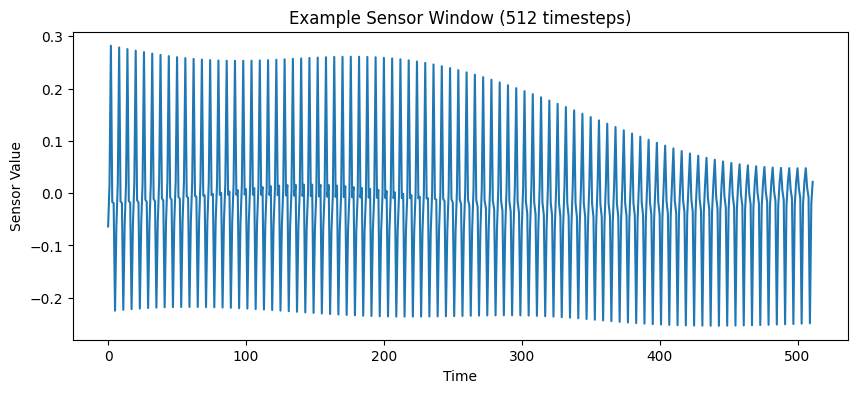

In [4]:

plt.figure(figsize=(10,4))
plt.plot(X_train[7]) # random number
plt.title("Example Sensor Window (512 timesteps)")
plt.xlabel("Time")
plt.ylabel("Sensor Value")
plt.show()

# Fall vs Non-Fall Visualization

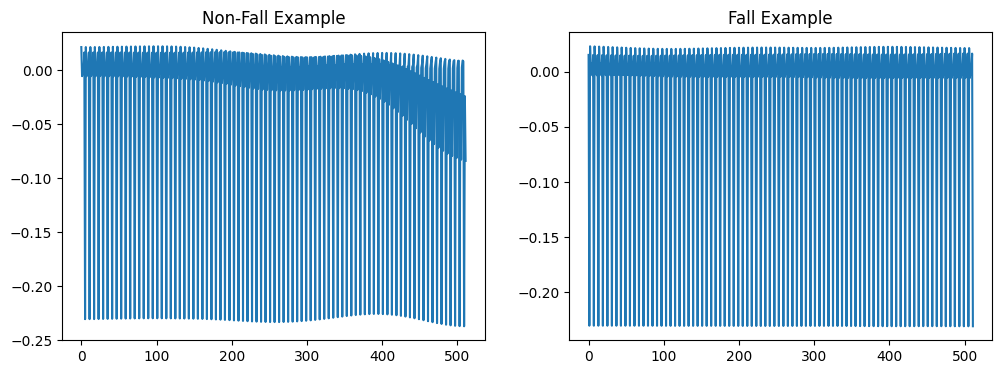

In [5]:
fall_idx = np.where(y_train == 1)[0][0]
nonfall_idx = np.where(y_train == 0)[0][0]

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(X_train[nonfall_idx])
plt.title("Non-Fall Example")

plt.subplot(1,2,2)
plt.plot(X_train[fall_idx])
plt.title("Fall Example")

plt.show()

# Prepare and Build CNN Model

In [6]:
# Reshape for CNN
X_train_cnn = X_train.reshape(-1, 512, 1)
X_val_cnn = X_val.reshape(-1, 512, 1)
X_test_cnn = X_test.reshape(-1, 512, 1)

# Lightweight CNN
model = Sequential([
    Conv1D(32, 5, activation='relu', input_shape=(512,1)),
    BatchNormalization(),
    MaxPooling1D(2),
    
    Conv1D(64, 3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(2),
    
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Binary output
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# Callbacks
early_stop = EarlyStopping(monitor='val_auc', patience=5, restore_best_weights=True, mode='max')
reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5)

# Class weights
cw = {0: class_weights[0], 1: class_weights[1]}

# Train
history = model.fit(
    X_train_cnn, y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=15,
    batch_size=512,
    class_weight=cw,
    callbacks=[early_stop, reduce_lr]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-10 23:39:15.447714: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/15
457/457 ━━━━━━━━━━━━━━━━━━━━ 156s 335ms/step - accuracy: 0.9294 - auc: 0.9781 - loss: 10.5384 - val_accuracy: 0.8899 - val_auc: 0.9625 - val_loss: 0.5289 - learning_rate: 0.0010
Epoch 2/15
457/457 ━━━━━━━━━━━━━━━━━━━━ 148s 325ms/step - accuracy: 0.9621 - auc: 0.9931 - loss: 5.2308 - val_accuracy: 0.9650 - val_auc: 0.9945 - val_loss: 0.1007 - learning_rate: 0.0010
Epoch 3/15
457/457 ━━━━━━━━━━━━━━━━━━━━ 152s 332ms/step - accuracy: 0.9652 - auc: 0.9944 - loss: 4.6175 - val_accuracy: 0.9687 - val_auc: 0.9954 - val_loss: 0.0841 - learning_rate: 0.0010
Epoch 4/15
457/457 ━━━━━━━━━━━━━━━━━━━━ 154s 337ms/step - accuracy: 0.9694 - auc: 0.9951 - loss: 4.1331 - val_accuracy: 0.9738 - val_auc: 0.9957 - val_loss: 0.0751 - learning_rate: 0.0010
Epoch 5/15
457/457 ━━━━━━━━━━━━━━━━━━━━ 150s 328ms/step - accuracy: 0.9713 - auc: 0.9956 - loss: 3.8495 - val_accuracy: 0.9702 - val_auc: 0.9961 - val_loss: 0.0867 - learning_rate: 0.0010
Epoch 6/15
457/457 ━━━━━━━━━━━━━━━━━━━━ 154s 337ms/step - a

##  Machine Learning Approach

To detect fall events from wearable sensor data, we train a **Convolutional Neural Network (CNN)**.

CNN models are particularly effective for time-series sensor signals because they can automatically detect patterns such as:

- abrupt changes in acceleration
- movement transitions
- characteristic fall signatures

The model learns these features directly from raw sensor data without requiring manual feature engineering.

### Model Architecture

The network includes:

- 1D convolution layers for extracting temporal features
- pooling layers for dimensionality reduction
- fully connected layers for classification

This architecture enables the model to capture **complex motion patterns associated with fall events.**

## Training the Model

The CNN model is trained using the labeled wearable sensor dataset.

During training, the model learns to distinguish between motion patterns associated with:

- normal daily activity
- unstable movement
- fall events

We evaluate model performance using metrics that are commonly used in **healthcare machine learning**, including:

- accuracy
- precision
- recall
- F1 score

These metrics are particularly important because **false negatives (missed falls)** and **false positives (false alarms)** have different real-world consequences.

In [7]:

# Predict probabilities
y_pred_prob = model.predict(X_test_cnn)

# Convert to 0/1 predictions
y_pred = (y_pred_prob > 0.5).astype(int)

print("Classification Report")
print(classification_report(y_test, y_pred, digits=4))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

1771/1771 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step
Classification Report
              precision    recall  f1-score   support

           0     0.9899    0.9709    0.9803     37768
           1     0.9440    0.9802    0.9618     18884

    accuracy                         0.9740     56652
   macro avg     0.9669    0.9756    0.9710     56652
weighted avg     0.9746    0.9740    0.9741     56652


Confusion Matrix
[[36669  1099]
 [  373 18511]]


## Model Performance

After training, the model is evaluated on an independent test dataset.

The results demonstrate strong performance in distinguishing fall-related motion patterns from normal activities.

The confusion matrix helps illustrate how often the model correctly identifies fall events and how often errors occur.

In healthcare monitoring systems, maintaining **high sensitivity for fall detection while minimizing false alarms** is essential for user trust and system reliability.

## Understanding Model Errors

Even well-performing models occasionally make mistakes.

To better understand these errors, we examine examples of misclassified signals. By visualizing these signals, we can observe cases where motion patterns are ambiguous or resemble both normal movement and fall events.

Error analysis helps identify potential improvements, such as:

- incorporating additional sensor modalities
- improving signal preprocessing
- using more advanced deep learning architectures

# Plot Training Curves

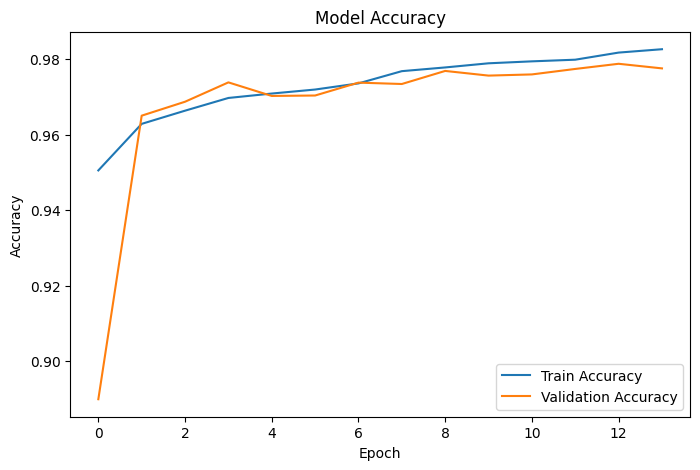

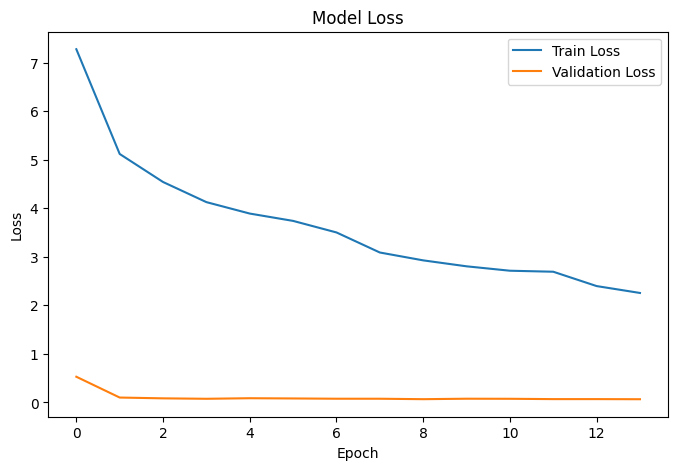

In [8]:

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# Model Evaluation and ROC Curve

1771/1771 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step


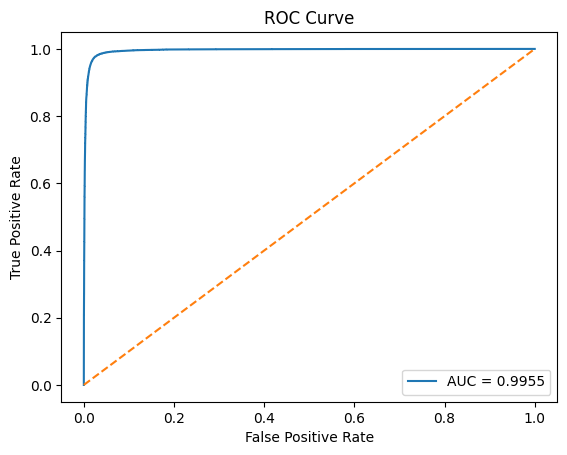

In [9]:

y_prob = model.predict(X_test_cnn)

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Precision-Recall Curve

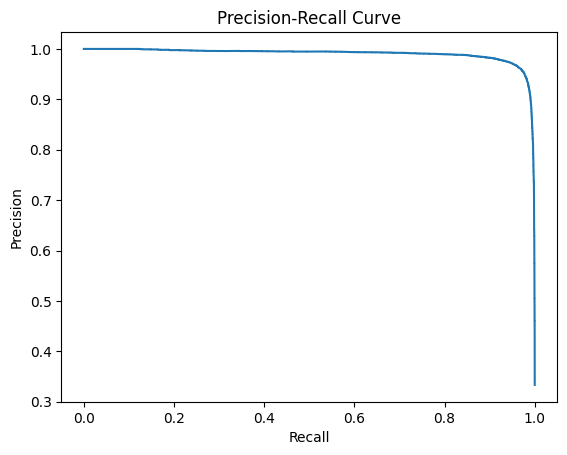

In [10]:

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

# Misclassification Analysis

In [11]:
mis_idx = np.where(y_pred.flatten() != y_test)[0]
print("Number of misclassified samples:", len(mis_idx))

Number of misclassified samples: 1472


# Plot Misclassified Example

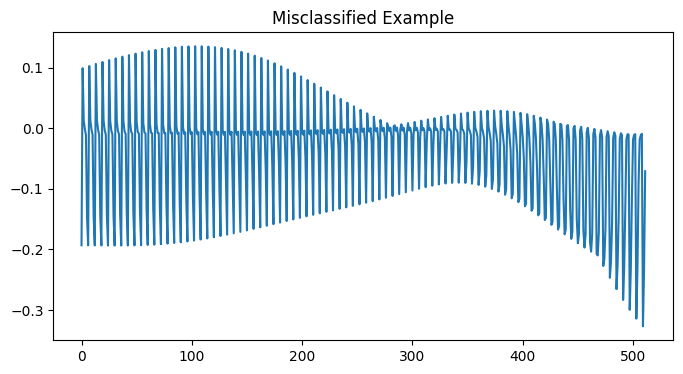

In [12]:
plt.figure(figsize=(8,4))
plt.plot(X_test[mis_idx[0]])
plt.title("Misclassified Example")
plt.show()

# Threshold Experiment

In [13]:
threshold = 0.3
y_pred_adjusted = (y_prob > threshold).astype(int)

print(confusion_matrix(y_test, y_pred_adjusted))

[[36235  1533]
 [  251 18633]]


# Baseline Model (Logistic Regression)

In [14]:

X_train_flat = X_train
X_test_flat = X_test

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_flat, y_train)

pred_lr = lr.predict(X_test_flat)

print(classification_report(y_test, pred_lr))

              precision    recall  f1-score   support

           0       0.89      0.97      0.93     37768
           1       0.93      0.75      0.83     18884

    accuracy                           0.90     56652
   macro avg       0.91      0.86      0.88     56652
weighted avg       0.90      0.90      0.90     56652



## Implications for Wearable Health Technologies

This project demonstrates how machine learning can analyze wearable sensor data to detect dangerous motion events.

Such systems could support a variety of healthcare applications, including:

- remote patient monitoring
- elderly fall detection systems
- rehabilitation tracking
- smart home safety technologies

With further development, wearable AI systems could enable **continuous health monitoring that enhances safety while preserving independence.**

## Conclusion

This notebook demonstrates a machine learning pipeline for detecting fall-related motion patterns using wearable sensor data.

By combining wearable technology with deep learning, it is possible to identify potentially dangerous movement patterns in real time.

These approaches represent an important step toward **intelligent health monitoring systems** that can support patients, caregivers, and clinicians.

Future work may focus on improving early fall detection, reducing false alarms, and enabling deployment in real-time wearable devices.